# DSML 4220 - Lab 6: Airline Tweets with (and without) Embeddings

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sgeinitz/DSML4220/blob/main/lab6_airline_tweets_w_embeddings.ipynb)

[![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/sgeinitz/DSML4220/blob/main/lab6_airline_tweets_w_embeddings.ipynb)

In this notebook we'll revisit the Airline Tweets dataset (from [Lab 1](https://github.com/sgeinitz/DSML4220/blob/main/lab1_text_data.ipynb)) and compare using an MLP with one-hot encodings as the input vs using word embeddings as the input.

In this lab there are three (3) questions/tasks. These questions are listed here but are also inline below.

1. Q1: Choose two words to compare (different from "_wonderful_" vs "_incredible_"). Re-run the parts of the notebook that plot the histogram of the differences between learned weight parameter values for each of your chosen words across the 128 hidden units in the first layer.
2. Q2: Add your two words the list of words whose embeddings are displayed and compared. Do your two chosen words have similar embeddings? In other words, is the distance between your embeddings very small?
3. Q3: Compare the size of the two models used in this notebook, one of which uses one-hot encoded inputs and the other which uses GloVe embeddings.

In [1]:
!pip install torchmetrics
!pip install torchinfo
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.1 MB/s eta 0:00:00


In [2]:
import torch
import random
import tqdm
import notebook
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import torchinfo
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchmetrics.functional import pairwise_cosine_similarity

In [3]:
data_URL = 'https://raw.githubusercontent.com/sgeinitz/DSML4220/main/data/airlinetweets.csv'
df = pd.read_csv(data_URL)
print(f"df.shape: {df.shape}")
pd.set_option("display.max_colwidth", 240)
df.head(10)

df.shape: (10000, 2)


,sentiment,text
0,positive,@JetBlue @JayVig I like the inflight snacks! I'm flying with you guys on 2/28! #JVMChat
1,positive,@VirginAmerica thanks guys! Sweet route over the Rockies #airplanemodewason
2,negative,@USAirways Your exchange/credit policies are worthless and shadier than the White House. Dissatisfied to the nines right now.
3,negative,@USAirways but in the meantime I'll be sleeping on a park bench on dadeland st. Thanks guys!
4,negative,@VirginAmerica hold times at call center are a bit much
5,negative,@USAirways not moving we are in the tarmac delayed for some unknown reason. I'll keep you posted
6,neutral,"@JetBlue What about if I booked it through Orbitz? My email is correct, but there's a middle party."
7,negative,@united 2nd flight also delayed no pilots! But they boarded is so we can just sit here! #scheduling
8,negative,".@AmericanAir after 50 minutes on hold, and another 30 minutes on the call yes. Going to be pushing it to get to the airport on time now"
9,positive,@JetBlue flight 117. proud to fly Jet Blue!


In [4]:
random.seed(2)
indices = list(range(len(df)))
random.shuffle(indices)

df_test = df.iloc[indices[9000:],]
df = df.iloc[indices[:9000],]

In [5]:
df_test.shape
df.shape

(9000, 2)

Recall that about 2/3 of the data have negative labels, and that the remaining labels are roughly split between positive and neutral (slightly more neutral than positive).

In [6]:
df.sentiment.value_counts(normalize=True)

,proportion
sentiment,
negative,0.653556
neutral,0.191111
positive,0.155333


Let's start with the nltk TweetTokenizer, which will split the text into separate words and characters based on common Twitter conventions.

In [7]:
from nltk.tokenize import TweetTokenizer
tk = TweetTokenizer()
df['tokens_raw'] = df['text'].apply(lambda x: tk.tokenize(x.lower()))
df.head()

,sentiment,text,tokens_raw
7010,positive,@AmericanAir I ended up on a flight to LA my fourth time on standby. Thanks! http://t.co/NA5G5EAKPA,"[@americanair, i, ended, up, on, a, flight, to, la, my, fourth, time, on, standby, ., thanks, !, http://t.co/na5g5eakpa]"
9477,neutral,@JetBlue thanks! I only loose 'em at airports...1st time we found it. I think @fitbit needs to make flexes that stay on when carrying bags!,"[@jetblue, thanks, !, i, only, loose, ', em, at, airports, ..., 1st, time, we, found, it, ., i, think, @fitbit, needs, to, make, flexes, that, stay, on, when, carrying, bags, !]"
4584,neutral,@SouthwestAir can take u to Midway-Chicago March 8th-April 6th. Can't make it then? @AmericanAir can get u to @fly2ohare year round. #FlyPBI,"[@southwestair, can, take, u, to, midway-chicago, march, 8th, -, april, 6th, ., can't, make, it, then, ?, @americanair, can, get, u, to, @fly2ohare, year, round, ., #flypbi]"
3460,negative,@AmericanAir is this how you let your employees treat your loyal customers? #attackingbabymomma #crazinessintherockies,"[@americanair, is, this, how, you, let, your, employees, treat, your, loyal, customers, ?, #attackingbabymomma, #crazinessintherockies]"
9065,negative,@USAirways so I still need to stay on hold? http://t.co/04SDytT7zd,"[@usairways, so, i, still, need, to, stay, on, hold, ?, http://t.co/04sdytt7zd]"


Previously, we did not do a lot of exploratory data analysis (EDA) on this airline tweet dataset. We will not do too much here either, but at the very least let's look at a histogram of the lengths of the tweets. Note that here we are defining length to be the number of tokens, but it may also be useful to look at the number of characters. And, of course, there are other EDA steps we could do.

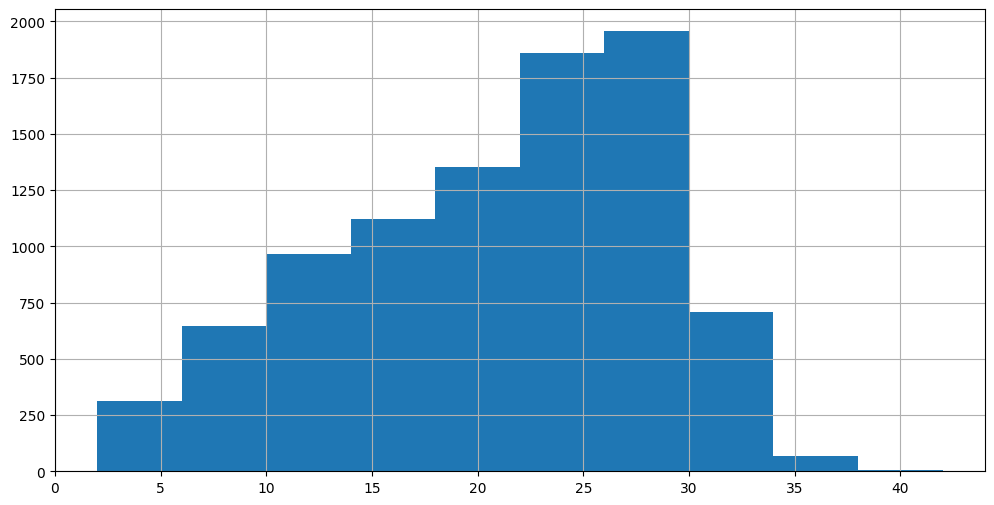

In [8]:
df['tweet_length'] = df['tokens_raw'].apply(lambda x: len(x))
plt.figure(figsize=(12,6))
df['tweet_length'].hist() #bins=100, range=(0,45), width=0.9) #, df['tweet_length'].mean(), df['tweet_length'].median()
plt.show()

In [9]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

Next, let's remove common stop words (e.g. "_the_", "_in_", etc.). In this next cell we will also remove some characters/punctuation, as well as hashtag tokens.

Note: If the following cell causes an error, then uncomment the code cell above and run it to download and load the nltk stopwords.

In [10]:
import re
from nltk.corpus import stopwords
stops = set(stopwords.words('english'))
chars2remove = set(['.','!','/', '?'])
df['tokens_raw'] = df['tokens_raw'].apply(lambda x: [w for w in x if w not in stops])
df['tokens_raw'] = df['tokens_raw'].apply(lambda x: [w for w in x if w not in chars2remove])
df['tokens_raw'] = df['tokens_raw'].apply(lambda x: [w for w in x if not re.match('^#', w)]) # remove hashtags
#df['tokens_raw'] = df['tokens_raw'].apply(lambda x: [w for w in x if not re.match('^http', w)]) # remove web links
#df['tokens_raw'] = df['tokens_raw'].apply(lambda x: [w for w in x if not re.match('^@', w)]) # remove web links

df.head()

,sentiment,text,tokens_raw,tweet_length
7010,positive,@AmericanAir I ended up on a flight to LA my fourth time on standby. Thanks! http://t.co/NA5G5EAKPA,"[@americanair, ended, flight, la, fourth, time, standby, thanks, http://t.co/na5g5eakpa]",18
9477,neutral,@JetBlue thanks! I only loose 'em at airports...1st time we found it. I think @fitbit needs to make flexes that stay on when carrying bags!,"[@jetblue, thanks, loose, ', em, airports, ..., 1st, time, found, think, @fitbit, needs, make, flexes, stay, carrying, bags]",31
4584,neutral,@SouthwestAir can take u to Midway-Chicago March 8th-April 6th. Can't make it then? @AmericanAir can get u to @fly2ohare year round. #FlyPBI,"[@southwestair, take, u, midway-chicago, march, 8th, -, april, 6th, can't, make, @americanair, get, u, @fly2ohare, year, round]",27
3460,negative,@AmericanAir is this how you let your employees treat your loyal customers? #attackingbabymomma #crazinessintherockies,"[@americanair, let, employees, treat, loyal, customers]",15
9065,negative,@USAirways so I still need to stay on hold? http://t.co/04SDytT7zd,"[@usairways, still, need, stay, hold, http://t.co/04sdytt7zd]",11


For the final step of text pre-processing we will lemmatize the tokens. Note that there are much better ways to do this but that we want to use a simple lemmatizer. For example, some lemmatizers also utilize a model internally to predict the part-of-speech for each word, since whether the word is a noun, adjective, verb, etc. will affect how lemmatization is done. Since we want to keep things simple here, and focus only on the lemmatization step, we'll assume every word is the same part of speech. Note that this is not by any means ideal (try to identify the incorrectly lemmatized token in the five tweets printed out below). In practice we would certainly utilize a 'smarter' lemmatizer.

The last step below is to combined the tokens back into a single string, which is stored in the column `textclean`.

In [11]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
# nltk.download('omw-1.4')
lemmatizer = WordNetLemmatizer()
df['tokens'] = df['tokens_raw'].apply(lambda x: [lemmatizer.lemmatize(w, pos="v") for w in x])
#df['tokens'] = df['tokens_raw'].apply(lambda x: [lemmatizer.lemmatize(w) for w in x])

df['textclean'] = df['tokens'].apply(lambda x: ' '.join(x))
df.head()

[nltk_data] Downloading package wordnet to /root/nltk_data...


,sentiment,text,tokens_raw,tweet_length,tokens,textclean
7010,positive,@AmericanAir I ended up on a flight to LA my fourth time on standby. Thanks! http://t.co/NA5G5EAKPA,"[@americanair, ended, flight, la, fourth, time, standby, thanks, http://t.co/na5g5eakpa]",18,"[@americanair, end, flight, la, fourth, time, standby, thank, http://t.co/na5g5eakpa]",@americanair end flight la fourth time standby thank http://t.co/na5g5eakpa
9477,neutral,@JetBlue thanks! I only loose 'em at airports...1st time we found it. I think @fitbit needs to make flexes that stay on when carrying bags!,"[@jetblue, thanks, loose, ', em, airports, ..., 1st, time, found, think, @fitbit, needs, make, flexes, stay, carrying, bags]",31,"[@jetblue, thank, loose, ', em, airports, ..., 1st, time, find, think, @fitbit, need, make, flex, stay, carry, bag]",@jetblue thank loose ' em airports ... 1st time find think @fitbit need make flex stay carry bag
4584,neutral,@SouthwestAir can take u to Midway-Chicago March 8th-April 6th. Can't make it then? @AmericanAir can get u to @fly2ohare year round. #FlyPBI,"[@southwestair, take, u, midway-chicago, march, 8th, -, april, 6th, can't, make, @americanair, get, u, @fly2ohare, year, round]",27,"[@southwestair, take, u, midway-chicago, march, 8th, -, april, 6th, can't, make, @americanair, get, u, @fly2ohare, year, round]",@southwestair take u midway-chicago march 8th - april 6th can't make @americanair get u @fly2ohare year round
3460,negative,@AmericanAir is this how you let your employees treat your loyal customers? #attackingbabymomma #crazinessintherockies,"[@americanair, let, employees, treat, loyal, customers]",15,"[@americanair, let, employees, treat, loyal, customers]",@americanair let employees treat loyal customers
9065,negative,@USAirways so I still need to stay on hold? http://t.co/04SDytT7zd,"[@usairways, still, need, stay, hold, http://t.co/04sdytt7zd]",11,"[@usairways, still, need, stay, hold, http://t.co/04sdytt7zd]",@usairways still need stay hold http://t.co/04sdytt7zd


Now we will perform one-hot encoding using sklearn's, `CountVectorizer`, with the option `binary=True`. We'll go ahead and call the resulting vectorized data, `X`, or `X_train` since it is only the training dataset. As with conventional statistical models, "_X_" represents the set of predictors, or independent variables.

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

#count_vectorizer = CountVectorizer(binary=True)
count_vectorizer = CountVectorizer(binary=True, min_df=2)
X_np = count_vectorizer.fit_transform(df['textclean']).toarray()

print(f"X_np.shape = {X_np.shape}")
type(X_np)

X_np.shape = (9000, 3842)


numpy.ndarray

Here is the full vocabulary created by the the `CountVectorizer`.

In [13]:
vocab = count_vectorizer.vocabulary_
vocab = {k: v for k, v in sorted(vocab.items(), key=lambda item: item[1], reverse=False)}
print(vocab)

{'00': 0, '000': 1, '01': 2, '02': 3, '03': 4, '05': 5, '05am': 6, '08': 7, '0hp': 8, '10': 9, '100': 10, '1000': 11, '101': 12, '1027': 13, '103': 14, '104': 15, '1081': 16, '10am': 17, '10hrs': 18, '10mins': 19, '10pm': 20, '10th': 21, '11': 22, '1109': 23, '1137': 24, '1142': 25, '117': 26, '1170': 27, '118': 28, '11am': 29, '11pm': 30, '11th': 31, '12': 32, '120': 33, '1200': 34, '1220': 35, '123': 36, '1230': 37, '1254': 38, '12pm': 39, '13': 40, '130': 41, '136': 42, '1389': 43, '13th': 44, '14': 45, '140': 46, '145': 47, '1472': 48, '15': 49, '150': 50, '152': 51, '1533': 52, '1534': 53, '1562': 54, '1571aus': 55, '15minutes': 56, '15th': 57, '16': 58, '1600': 59, '1613': 60, '1625': 61, '165': 62, '1657': 63, '17': 64, '1700': 65, '1701': 66, '174': 67, '18': 68, '180': 69, '1800': 70, '1826': 71, '1861': 72, '1898': 73, '19': 74, '1917': 75, '1970': 76, '1997': 77, '1am': 78, '1hr': 79, '1k': 80, '1m': 81, '1pm': 82, '1st': 83, '1ywxrfn0gr': 84, '20': 85, '200': 86, '2000': 87

---

### Q1: Choose two words to compare (different from "_wonderful_" vs "_incredible_").

Below you will choose your two words, which have similar meaning and which you suspect the model will treat similarly. Then, re-train the model and plot the histogram of the differences between learned weight values for each of your chosen words across the 128 hidden units in the first layer. Did the histograms show that the learned weight values were similar for your words? More similar than for the neighboring words compared to each other?

`Apologize vs Apology`

---

In [14]:
word1 = 'apologize'   # input your own word here
word2 = 'apology'  # and a synonym for your word here

word1_idx = vocab[word1]
print(f"The index for '{word1}': {word1_idx}")

word2_idx = vocab[word2]
print(f"The index for '{word2}': {word2_idx}")


The index for 'apologize': 470
The index for 'apology': 471


Next, let's look at the tweets themselves that contained the word _"great"_.

In [15]:
rows_w_word1 = np.where(X_np[:, word1_idx] == 1)[0]
print(rows_w_word1)
df.iloc[rows_w_word1,]

[  40 1279 1542 2511 2740 5247 6816 8200 8430]


,sentiment,text,tokens_raw,tweet_length,tokens,textclean
9747,negative,@AndrewFallis same here! On hold for an hour &amp; then told @USAirways has done all it is willing to- which was apologize. #stillnotonmyflight,"[@andrewfallis, hold, hour, &, told, @usairways, done, willing, -, apologize]",26,"[@andrewfallis, hold, hour, &, tell, @usairways, do, will, -, apologize]",@andrewfallis hold hour & tell @usairways do will - apologize
2793,positive,@SouthwestAir just got a call apologizing personally for the long waits last week trying to rebook flights. Class act. I appreciate that!,"[@southwestair, got, call, apologizing, personally, long, waits, last, week, trying, rebook, flights, class, act, appreciate]",25,"[@southwestair, get, call, apologize, personally, long, wait, last, week, try, rebook, flight, class, act, appreciate]",@southwestair get call apologize personally long wait last week try rebook flight class act appreciate
3994,negative,@AmericanAir and just bad cs! I will be back on @JetBlue at least when you stuck they look out for you and apologize for any trouble,"[@americanair, bad, cs, back, @jetblue, least, stuck, look, apologize, trouble]",27,"[@americanair, bad, cs, back, @jetblue, least, stick, look, apologize, trouble]",@americanair bad cs back @jetblue least stick look apologize trouble
7429,negative,"“@AmericanAir: @mwangbickler We apologize for your frustrations, Michael. Have you been rebooked?” -got call back after 10 hours. Bad.","[“, @americanair, :, @mwangbickler, apologize, frustrations, ,, michael, rebooked, ”, -, got, call, back, 10, hours, bad]",28,"[“, @americanair, :, @mwangbickler, apologize, frustrations, ,, michael, rebooked, ”, -, get, call, back, 10, hours, bad]","“ @americanair : @mwangbickler apologize frustrations , michael rebooked ” - get call back 10 hours bad"
4415,negative,"@AmericanAir stranded for 24 hours in MIA, Patrick casimir has been the ONLY AA staff to apologize for the great inconvenience #unreal","[@americanair, stranded, 24, hours, mia, ,, patrick, casimir, aa, staff, apologize, great, inconvenience]",23,"[@americanair, strand, 24, hours, mia, ,, patrick, casimir, aa, staff, apologize, great, inconvenience]","@americanair strand 24 hours mia , patrick casimir aa staff apologize great inconvenience"
5541,positive,@united no worries Your customer service gets a bad wrap but just spoke w agent who saved me huge amounts of time &amp; apologized for yesterday,"[@united, worries, customer, service, gets, bad, wrap, spoke, w, agent, saved, huge, amounts, time, &, apologized, yesterday]",26,"[@united, worry, customer, service, get, bad, wrap, speak, w, agent, save, huge, amount, time, &, apologize, yesterday]",@united worry customer service get bad wrap speak w agent save huge amount time & apologize yesterday
6130,negative,"@united Apologize to the President. Once those employees blamed him, I heard it repeated 20 times.","[@united, apologize, president, employees, blamed, ,, heard, repeated, 20, times]",19,"[@united, apologize, president, employees, blame, ,, hear, repeat, 20, time]","@united apologize president employees blame , hear repeat 20 time"
2178,negative,@SouthwestAir Don't apologize. Do something about it. Words mean nothing. Actions work. EOM.,"[@southwestair, apologize, something, words, mean, nothing, actions, work, eom]",18,"[@southwestair, apologize, something, word, mean, nothing, action, work, eom]",@southwestair apologize something word mean nothing action work eom
2679,negative,@AmericanAir Unfortunately that is not true. A robot apologizes and hangs up. So how do I get help?,"[@americanair, unfortunately, true, robot, apologizes, hangs, get, help]",21,"[@americanair, unfortunately, true, robot, apologize, hang, get, help]",@americanair unfortunately true robot apologize hang get help


In [16]:
rows_w_word2 = np.where(X_np[:, word2_idx] == 1)[0]
print(rows_w_word2)
df.iloc[rows_w_word2,]

[ 315  389  541  864  955 1024 1413 1468 1547 2400 2460 2524 2955 3394
 3895 4885 4905 5321 6620 7202 7686 7783 7898 8208 8395 8432 8482 8638]


,sentiment,text,tokens_raw,tweet_length,tokens,textclean
1380,negative,@AmericanAir @yvonneokaka When do I get my personal response and apology for your crew's having forgotten to load baggage onto my flight?,"[@americanair, @yvonneokaka, get, personal, response, apology, crew's, forgotten, load, baggage, onto, flight]",23,"[@americanair, @yvonneokaka, get, personal, response, apology, crew's, forget, load, baggage, onto, flight]",@americanair @yvonneokaka get personal response apology crew's forget load baggage onto flight
7852,negative,@United Airlines Cancelled Flights OC FLL #flight today. $700 to switch. No notice no apology. We are done flying #UnitedAirlines.,"[@united, airlines, cancelled, flights, oc, fll, today, $, 700, switch, notice, apology, done, flying]",25,"[@united, airlines, cancel, flight, oc, fll, today, $, 700, switch, notice, apology, do, fly]",@united airlines cancel flight oc fll today $ 700 switch notice apology do fly
6222,negative,@united no apology? Cool.,"[@united, apology, cool]",6,"[@united, apology, cool]",@united apology cool
3406,negative,@united @dfpietra THAT'S your response? Shaking my head back and forth with a tsk. You can do better-from customer service to your apology,"[@united, @dfpietra, that's, response, shaking, head, back, forth, tsk, better-from, customer, service, apology]",25,"[@united, @dfpietra, that's, response, shake, head, back, forth, tsk, better-from, customer, service, apology]",@united @dfpietra that's response shake head back forth tsk better-from customer service apology
8504,negative,"@USAirways asked her why needed to take yellow tag off. She said, ""because I told you to!"" Expect a personal apology from her- unacceptable!","[@usairways, asked, needed, take, yellow, tag, said, ,, "", told, "", expect, personal, apology, -, unacceptable]",31,"[@usairways, ask, need, take, yellow, tag, say, ,, "", tell, "", expect, personal, apology, -, unacceptable]","@usairways ask need take yellow tag say , "" tell "" expect personal apology - unacceptable"
529,negative,@AmericanAir understand the weather but would be nice to hear an apology on the phone when you moved my flight to an inconvenient day,"[@americanair, understand, weather, would, nice, hear, apology, phone, moved, flight, inconvenient, day]",24,"[@americanair, understand, weather, would, nice, hear, apology, phone, move, flight, inconvenient, day]",@americanair understand weather would nice hear apology phone move flight inconvenient day
8510,negative,@united Well the bar is set low! You guys are really good at the apology game! What will change? When will u guys learn?,"[@united, well, bar, set, low, guys, really, good, apology, game, change, u, guys, learn]",28,"[@united, well, bar, set, low, guy, really, good, apology, game, change, u, guy, learn]",@united well bar set low guy really good apology game change u guy learn
1967,negative,@united Missed KTM flight due to ur Cancelled Flightlation. Mike supervisor disgusting. Now day Late Flight. No apology or upgrade offer to LHR from ORD???,"[@united, missed, ktm, flight, due, ur, cancelled, flightlation, mike, supervisor, disgusting, day, late, flight, apology, upgrade, offer, lhr, ord]",31,"[@united, miss, ktm, flight, due, ur, cancel, flightlation, mike, supervisor, disgust, day, late, flight, apology, upgrade, offer, lhr, ord]",@united miss ktm flight due ur cancel flightlation mike supervisor disgust day late flight apology upgrade offer lhr ord
7473,negative,"@AmericanAir 3231DTW to LAG at 4:45. Flight Cancelled Flightled with no notice. Given a voucher to a dirty hotel, with no food vouchers or apology.","[@americanair, 3231dtw, lag, 4:45, flight, cancelled, flightled, notice, given, voucher, dirty, hotel, ,, food, vouchers, apology]",29,"[@americanair, 3231dtw, lag, 4:45, flight, cancel, flightled, notice, give, voucher, dirty, hotel, ,, food, vouchers, apology]","@americanair 3231dtw lag 4:45 flight cancel flightled notice give voucher dirty hotel , food vou

Confirm that the input, `X`, has n rows and a column for each word (token) in the vocabulary.

In [17]:
X = torch.tensor(X_np).float()
X.size()

torch.Size([9000, 3842])

In [18]:
# look at one observation and see how may tokens there are (i.e. how many 1's are in the row, and how many 0's)
pd.DataFrame(X_np[1,:]).value_counts()

,count
0,
0,3827
1,15


In [19]:
labels = df['sentiment'].unique()
enum_labels = enumerate(labels)
label_to_idx = dict((lab, i) for i,lab in enum_labels)
print(f"label dictionary: {label_to_idx}")
y = torch.tensor([label_to_idx[lab] for lab in df['sentiment']])

label dictionary: {'positive': 0, 'neutral': 1, 'negative': 2}


In [20]:
class AirlineTweetDataset(Dataset):
    def __init__(self, observations, labels):
        self.obs = observations
        self.labs = labels
        self.create_split(len(observations))

    def create_split(self, n, seed=2, train_perc=0.7):
        random.seed(seed)
        indices = list(range(n))
        random.shuffle(indices)
        self._train_ids = list(indices[:int(n * train_perc)])
        self._test_ids = list(indices[int(n * train_perc):])
        self._split_X = self.obs[self._train_ids]
        self._split_y = self.labs[self._train_ids]

    def set_split(self, split='train'):
        if split == 'train':
            self._split_X = self.obs[self._train_ids]
            self._split_y = self.labs[self._train_ids]
        else:
            self._split_X = self.obs[self._test_ids]
            self._split_y = self.labs[self._test_ids]

    def __len__(self):
        return len(self._split_y)

    def __getitem__(self, idx):
        return {'x':self._split_X[idx], 'y':self._split_y[idx]}

    def get_num_batches(self, batch_size):
        return len(self) // batch_size

dataset = AirlineTweetDataset(X, y)
dataset.create_split(len(X), seed=42, train_perc=0.85)

In [21]:
dataset.set_split('train')
print(f"len(dataset) = {len(dataset)}")
#len(dataset[:]['x'])
dataset[0]['x']

len(dataset) = 7650


tensor([0., 0., 0.,  ..., 0., 0., 0.])

Confirm that there are no NaN, and that all numerical values are finite.

In [22]:
dataset[:]['x'].numpy()[0,:5]

array([0., 0., 0., 0., 0.], dtype=float32)

In [23]:
assert not np.any(np.isnan(dataset[:]['x'].numpy()))
assert np.all(np.isfinite(dataset[:]['x'].numpy()))

In [24]:
class AirlineTweetClassifier(nn.Module):
    """ A 2-layer Multilayer Perceptron for classifying surnames """
    def __init__(self, input_dim, hidden_dim, output_dim):
        """
        Args:
            input_dim (int): the size of the input embeddings
            hidden_dim (int): the output size of the first Linear layer
            output_dim (int): the output size of the second Linear layer
        """
        super(AirlineTweetClassifier, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 32)
        self.fc3 = nn.Linear(32, output_dim)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x_in, apply_softmax=False):
        """The forward pass of the classifier

        Args:
            x_in (torch.Tensor): an input data tensor.
                x_in.shape should be (batch, input_dim)
            apply_softmax (bool): a flag for the softmax activation
                should be false if used with the Cross Entropy losses
        Returns:
            the resulting tensor. tensor.shape should be (batch, output_dim)
        """
        intermediate_vector = F.relu(self.fc1(x_in))

        intermediate_vector = F.relu(self.fc2(intermediate_vector))
        intermediate_vector = self.dropout(intermediate_vector)

        prediction_vector = self.fc3(intermediate_vector)

        if apply_softmax:
            prediction_vector = F.softmax(prediction_vector, dim=1)

        return prediction_vector

#### Hyperparameters for model with one-hot encoded inputs

In [25]:
batch_size = 32
learning_rate = 0.001
num_epochs = 20
device = 'cpu'

dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)

Take one quick look at the size of the training and validation splits.

In [26]:
dataset.set_split('train')
print(len(dataloader) * batch_size)
dataset.set_split('val')
print(len(dataloader) * batch_size)

7680
1376


In [27]:
seed = 2
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

# create the dataset, model and define loss function and optimizer
model = AirlineTweetClassifier(len(dataset[0]['x']), 128, 3)
loss_fun = nn.CrossEntropyLoss()#weights)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [28]:
epoch_bar = tqdm.notebook.tqdm(desc='training routine', total=num_epochs, position=0)

dataset.set_split('train')
train_bar = tqdm.notebook.tqdm(desc='split=train', total=dataset.get_num_batches(batch_size), position=1, leave=True)

dataset.set_split('val')
val_bar = tqdm.notebook.tqdm(desc='split=val', total=dataset.get_num_batches(batch_size), position=1, leave=True)

losses = {'train':[], 'val':[]}

for epoch in range(num_epochs):

    dataset.set_split('train')
    model.train()
    running_loss_train = 0.0

    for batch_i, batch_data in enumerate(dataloader):
        tweets = batch_data['x'].to(device)
        labels = batch_data['y'].to(device)

        # forward
        outputs = model(tweets)
        loss = loss_fun(outputs, labels)
        losses['train'].append(loss.item())
        running_loss_train += loss.item()

        # backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #if (batch_i+1) % 10 == 0:
        #    print(f"    train batch {batch_i+1:3.0f} (of {len(dataloader):3.0f}) loss: {loss.item():.4f}")
            # update bar
        train_bar.set_postfix(loss=running_loss_train, epoch=epoch)
        train_bar.update()

    train_bar.set_postfix(loss=running_loss_train/dataset.get_num_batches(batch_size), epoch=epoch)
    train_bar.update()


    running_loss_train = running_loss_train / len(dataset)

    dataset.set_split('val')
    model.eval() # turn off the automatic differentiation
    running_loss_val = 0.0

    for batch_i, batch_data in enumerate(dataloader):
        tweets = batch_data['x'].to(device)
        labels = batch_data['y'].to(device)


        # forward (no backward step for validation data)
        outputs = model(tweets)
        loss = loss_fun(outputs, labels)
        losses['val'].append(loss.item())
        running_loss_val += loss.item()
        #if (batch_i+1) % 20 == 0:
        #    print(f"    valid batch {i+1:3.0f} (of {len(dataloader):3.0f}) loss: {loss.item():.4f}")
        val_bar.set_postfix(loss=running_loss_val, epoch=epoch)
        val_bar.update()

    val_bar.set_postfix(loss=running_loss_val/dataset.get_num_batches(batch_size), epoch=epoch)
    val_bar.update()

    train_bar.n = 0
    val_bar.n = 0
    epoch_bar.update()

    running_loss_val = running_loss_val / len(dataset)


training routine:   0%|          | 0/20 [00:00<?, ?it/s]

split=train:   0%|          | 0/239 [00:00<?, ?it/s]

split=val:   0%|          | 0/42 [00:00<?, ?it/s]

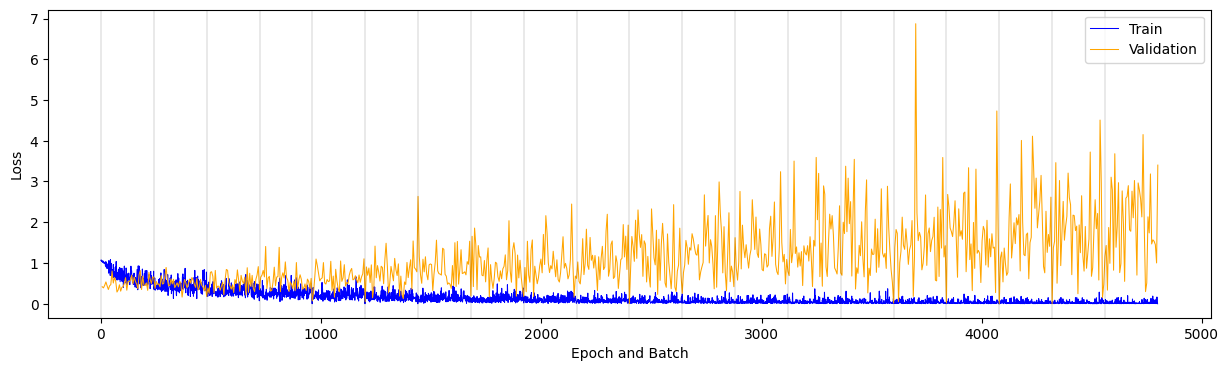

In [29]:
matplotlib.rc('figure', figsize=(15,4))
val_ticks = [(i+1)*len(losses['train'])/len(losses['val']) for i in range(len(losses['val']))]
plt.plot(range(len(losses['train'])), losses['train'], c='blue', lw=0.75)
plt.plot(val_ticks, losses['val'], c='orange', lw=0.75)
for i in range(num_epochs):
    plt.axvline(x=i*len(losses['train'])/num_epochs, c='black', lw=0.25, alpha=0.5)
plt.ylabel('Loss')
plt.xlabel('Epoch and Batch')
plt.legend(('Train','Validation'))

In [30]:
# Test the model on full validation set
dataset.set_split('val')

y_true = []
y_pred = []
with torch.no_grad():
    correct = 0
    total = 0
    for batch_data in dataloader:
        tweets = batch_data['x'].to(device)
        labels = batch_data['y'].to(device)
        outputs = model(tweets)
        _, predicted = torch.max(outputs.data, 1)
        y_true += labels.tolist()
        y_pred += predicted.tolist()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Accuracy (on {len(dataloader)*batch_size} validation tweets): {100 * correct / total:.2f}%")


Accuracy (on 1376 validation tweets): 80.22%


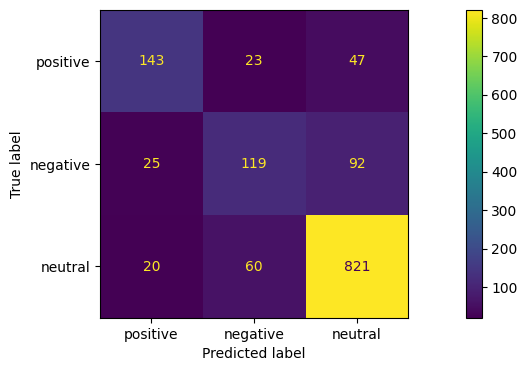

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['positive','negative','neutral'])
disp.plot()

In [32]:
torchinfo.summary(model, tuple(dataset[0]['x'].size()))

Layer (type:depth-idx)                   Output Shape              Param #
AirlineTweetClassifier                   [3]                       --
├─Linear: 1-1                            [128]                     491,904
├─Linear: 1-2                            [32]                      4,128
├─Dropout: 1-3                           [32]                      --
├─Linear: 1-4                            [3]                       99
Total params: 496,131
Trainable params: 496,131
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 63.10
Input size (MB): 0.02
Forward/backward pass size (MB): 0.00
Params size (MB): 1.98
Estimated Total Size (MB): 2.00

Let's now retrieve the weight parameters that are associated with the words (i.e. tokens) that have similar meaning, "wonderful", "incredible", "terrific". These words were in the vocabulary at following locations.
* index for 'wonderful': 3782
* index for 'incredible': 1930
* index for 'terrific': 3425

In [33]:
fc1_weights = model.fc1.weight.data
print(f"first model layer has weight matrix with shape = {fc1_weights.shape}")

first model layer has weight matrix with shape = torch.Size([128, 3842])


In [34]:
#wonderful_idx = vocab['wonderful']
#incredible_idx = vocab['incredible']
unit_i = 0
print(f"word1 index: {word1_idx}")
print(f"  fc1_weights[{unit_i},{[word1_idx-1,word1_idx, word1_idx+1]}]: {fc1_weights[unit_i,word1_idx-1:word1_idx+2]}")
print(f"word2 index: {word2_idx}")
print(f"  fc1_weights[{unit_i},{[word2_idx-1,word2_idx, word2_idx+1]}]: {fc1_weights[unit_i,word2_idx-1:word2_idx+2]}")

word1 index: 470
  fc1_weights[0,[469, 470, 471]]: tensor([ 0.0214, -0.0268,  0.1414], device='cuda:0')
word2 index: 471
  fc1_weights[0,[470, 471, 472]]: tensor([-0.0268,  0.1414, -0.0620], device='cuda:0')


In [38]:
diffs = {"cont1":[], "word1_vs_word2":[], "cont2":[]}
for i in range(128):
    diffs["cont1"].append(abs(fc1_weights[i,word1_idx-1].cpu() - fc1_weights[i,word2_idx-1].cpu()))
    diffs["word1_vs_word2"].append(abs(fc1_weights[i,word1_idx].cpu() - fc1_weights[i,word2_idx].cpu()))
    diffs["cont2"].append(abs(fc1_weights[i,word1_idx+1].cpu() - fc1_weights[i,word2_idx+1].cpu()))

# convert each list to a numpy array
for key in diffs:
    diffs[key] = np.array(diffs[key])

In [39]:
# generate summary statistics for the differences for weight values
diffs_df = pd.DataFrame(diffs)
diffs_df.describe()

,cont1,word1_vs_word2,cont2
count,128.000000,128.000000,128.000000
mean,0.056498,0.082875,0.083048
std,0.025348,0.045971,0.045790
min,0.000809,0.000506,0.001015
25%,0.037251,0.047352,0.054883
50%,0.059676,0.080782,0.080776
75%,0.074658,0.119307,0.106091
max,0.112358,0.193480,0.235808


In [40]:
vocab = count_vectorizer.vocabulary_

# find which key vocab is associated with the index 4139
for key, value in vocab.items():
    if value == word1_idx-1:
        w_at_incredible_idx_minus_1 = key
        print(f"word at index {word1_idx-1}: {key}")
    if value == word2_idx-1:
        w_at_wonderful_idx_minus_1 = key
        print(f"word at index {word2_idx-1}: {key}")
    if value == word1_idx+1:
        w_at_incredible_idx_plus_1 = key
        print(f"word at index {word1_idx+1}: {key}")
    if value == word2_idx+1:
        w_at_wonderful_idx_plus_1 = key
        print(f"word at index {word2_idx+1}: {key}")



word at index 470: apologize
word at index 472: app
word at index 471: apology
word at index 469: apologise


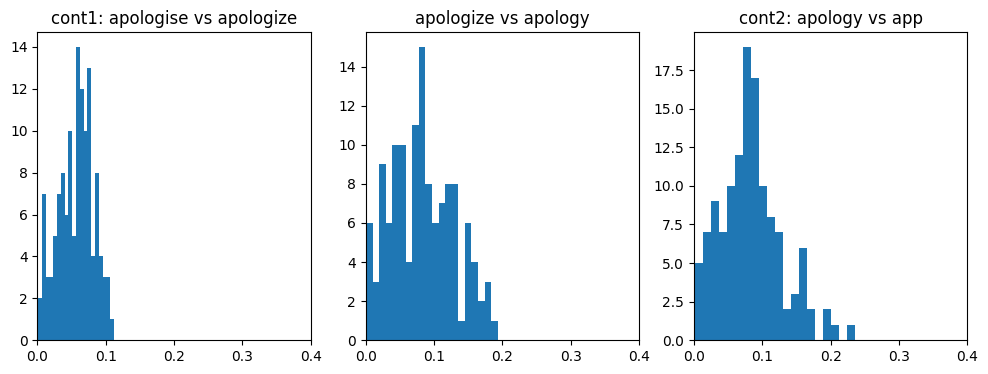

In [41]:
# plots of the differences as three different histograms
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(diffs["cont1"], bins=20)
# set x-axis limits to be the same for all three plots
plt.xlim(0,0.4)
plt.title(f"cont1: {w_at_incredible_idx_minus_1} vs {w_at_wonderful_idx_minus_1}")
plt.subplot(1,3,2)
plt.hist(diffs["word1_vs_word2"], bins=20)
plt.xlim(0,0.4)
plt.title(f"{word1} vs {word2}")
plt.subplot(1,3,3)
plt.hist(diffs["cont2"], bins=20)
plt.xlim(0,0.4)
plt.title(f"cont2: {w_at_incredible_idx_plus_1} vs {w_at_wonderful_idx_plus_1}")
plt.show()


In [42]:
# length of an input is
len(dataset[0]['x'])

3842

In [43]:
import gensim.downloader as api

# Download and load the 'glove-wiki-gigaword-100' model (100 dimensions)
vec = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


---

### Q1: Choose two words to compare (different from "_wonderful_" vs "_incredible_").

Below you will choose your two words, which have similar meaning and which you suspect the model will treat similarly. Then, re-train the model and plot the histogram of the differences between learned weight values for each of your chosen words across the 128 hidden units in the first layer. Did the histograms show that the learned weight values were similar for your words? More similar than for the neighboring words compared to each other?

`Apolgize vs Apology. These two words have a similiar weight. But less similiar then neighboring words`

---

In [44]:
examples = ['annoy', 'annoyed', 'disappointed', 'sad', 'happy', 'pilot', 'attendant', 'crew', 'suitcase', 'luggage', 'carryon', 'wonderful', 'incredible', 'terrific','great']
embeddings = vec[examples]
embeddings[0,:] # just the first embedding (you can verify by confirming that it is 100 elements long)

array([-0.70358  ,  0.0086422,  0.70049  , -0.48367  , -0.47212  ,
        0.80755  , -0.34986  , -0.65808  ,  1.0569   ,  0.013269 ,
        0.18186  ,  0.070198 ,  0.022501 , -0.28717  , -0.036474 ,
       -0.091136 , -0.45434  ,  0.13779  , -0.41533  ,  0.42545  ,
        0.09145  , -0.73157  ,  0.1225   ,  0.11498  ,  0.56402  ,
       -0.12488  , -0.52666  , -0.26781  ,  0.59911  , -0.25107  ,
       -0.069892 ,  0.2608   ,  0.63636  , -0.051941 , -0.88315  ,
        0.53447  , -0.021251 , -0.24914  , -0.020145 , -0.2569   ,
        0.077433 ,  0.17501  , -0.73515  , -0.50129  , -0.52672  ,
       -0.016783 ,  0.93297  ,  0.1701   ,  0.046011 , -0.56815  ,
       -0.46794  , -0.076335 , -0.61941  , -0.24247  , -0.33828  ,
        0.65989  ,  0.68259  , -0.43018  , -0.47939  , -0.54677  ,
       -0.58047  ,  0.57127  ,  0.25237  ,  0.42919  , -0.4386   ,
        0.70033  ,  0.72565  ,  0.35898  ,  0.40513  , -0.13125  ,
       -0.13079  , -0.49381  ,  0.11575  , -0.5328   , -0.1381

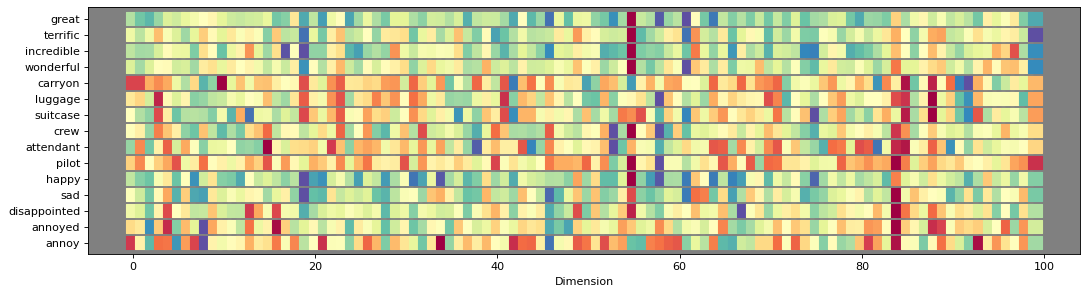

In [45]:
def compare_words_with_colors(vecs, wds):
    wdsr = wds[:]
    wdsr.reverse()

    dim = len(vecs[0])

    fig = plt.figure(num=None, figsize=(16, 4), dpi=80, facecolor='w', edgecolor='k')
    ax = fig.add_subplot(111)
    ax.set_facecolor('gray')

    for i,v in enumerate(vecs):
        ax.scatter(range(dim), [i]*dim, c=vecs[i], cmap='Spectral', s=150, marker='s')

    #plt.xticks(range(100), [i+1 for i in range(100)])
    plt.xlabel('Dimension')
    plt.yticks(range(len(wds)), wds)

    plt.show()

compare_words_with_colors(embeddings, examples)
#examples.reverse()

In [46]:
emb1 = embeddings[0]

In [47]:
# CosineSimilarity over the embedding dimension
cos = torch.nn.CosineSimilarity(dim=2)

# Compare every embedding to every other embedding
# Shapes become:
#   a: (16, 1, 100)
#   b: (1, 16, 100)
# Broadcasting gives pairwise comparisons of shape (16, 16, 100)
a = torch.tensor(embeddings).unsqueeze(1)
b = torch.tensor(embeddings).unsqueeze(0)

# Result is a 16 x 16 matrix of scalar cosine similarities
sim_matrix = cos(a, b)   # shape: (16, 16)

# Convert to pandas DataFrame
similarities = pd.DataFrame(
    sim_matrix.numpy(),
    index=[f"emb_{i}" for i in range(embeddings.shape[0])],
    columns=[f"emb_{i}" for i in range(embeddings.shape[0])]
)

print(similarities.shape)

(15, 15)


In [ ]:
similarities

In [48]:
# rename the rows and columns of similarities using 'examples'
similarities.columns = examples
similarities.index = examples
similarities

np.fill_diagonal(similarities.values, None)


In the cell above we created a similarity matrix, let's now see what it looks like. Note that since we are plotting pairwise similarities, larger values will be green and will suggest that the word the corresponding row is close to the word in the corresponding columns (and vice versa).

Similarly, words that are not similar to each other will have a low similarity, and will be plotted in red.

<Axes: >

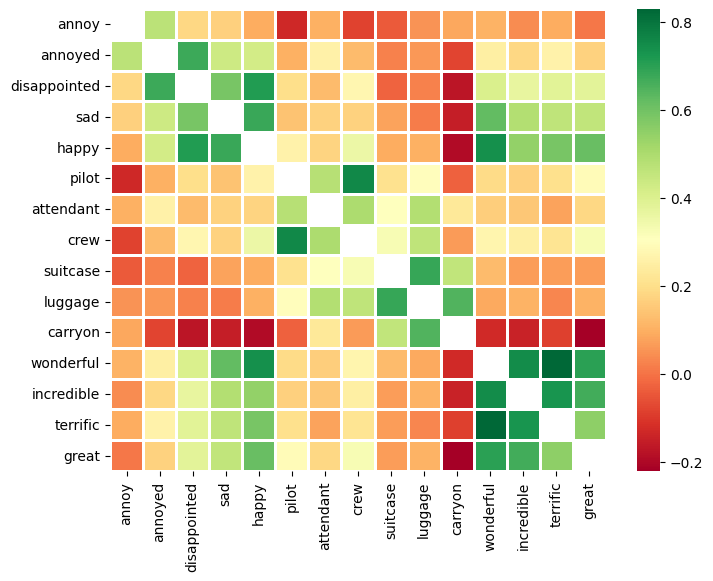

In [49]:
plt.figure(figsize=(8,6))
sns.color_palette("viridis", as_cmap=True)
#sns.color_palette("mako", as_cmap=True)
sns.heatmap(
    similarities,
    cmap='RdYlGn',  # Reverse the 'RdYlGn' colormap to have green for larger values and red for smaller values
    linewidth=1
)


In [50]:
data_URL = 'https://raw.githubusercontent.com/sgeinitz/DSML4220/main/data/airlinetweets.csv'
df = pd.read_csv(data_URL)
print(f"df.shape: {df.shape}")
pd.set_option("display.max_colwidth", 240)
df.head(10)

df.shape: (10000, 2)


,sentiment,text
0,positive,@JetBlue @JayVig I like the inflight snacks! I'm flying with you guys on 2/28! #JVMChat
1,positive,@VirginAmerica thanks guys! Sweet route over the Rockies #airplanemodewason
2,negative,@USAirways Your exchange/credit policies are worthless and shadier than the White House. Dissatisfied to the nines right now.
3,negative,@USAirways but in the meantime I'll be sleeping on a park bench on dadeland st. Thanks guys!
4,negative,@VirginAmerica hold times at call center are a bit much
5,negative,@USAirways not moving we are in the tarmac delayed for some unknown reason. I'll keep you posted
6,neutral,"@JetBlue What about if I booked it through Orbitz? My email is correct, but there's a middle party."
7,negative,@united 2nd flight also delayed no pilots! But they boarded is so we can just sit here! #scheduling
8,negative,".@AmericanAir after 50 minutes on hold, and another 30 minutes on the call yes. Going to be pushing it to get to the airport on time now"
9,positive,@JetBlue flight 117. proud to fly Jet Blue!


In [51]:
df.head()

,sentiment,text
0,positive,@JetBlue @JayVig I like the inflight snacks! I'm flying with you guys on 2/28! #JVMChat
1,positive,@VirginAmerica thanks guys! Sweet route over the Rockies #airplanemodewason
2,negative,@USAirways Your exchange/credit policies are worthless and shadier than the White House. Dissatisfied to the nines right now.
3,negative,@USAirways but in the meantime I'll be sleeping on a park bench on dadeland st. Thanks guys!
4,negative,@VirginAmerica hold times at call center are a bit much


In [52]:
random.seed(2)
indices = list(range(len(df)))
random.shuffle(indices)

df_test = df.iloc[indices[9000:],]
df = df.iloc[indices[:9000],]

In [53]:
df.sentiment.value_counts(normalize=False)

,count
sentiment,
negative,5882
neutral,1720
positive,1398


In [54]:
# use gensim to tokenize the text, so that we can then retrieve the embedding for each token
from gensim.utils import tokenize
df['tokens_raw'] = df['text'].apply(lambda x: list(tokenize(x.lower())))
df.head()

,sentiment,text,tokens_raw
7010,positive,@AmericanAir I ended up on a flight to LA my fourth time on standby. Thanks! http://t.co/NA5G5EAKPA,"[americanair, i, ended, up, on, a, flight, to, la, my, fourth, time, on, standby, thanks, http, t, co, na, g, eakpa]"
9477,neutral,@JetBlue thanks! I only loose 'em at airports...1st time we found it. I think @fitbit needs to make flexes that stay on when carrying bags!,"[jetblue, thanks, i, only, loose, em, at, airports, st, time, we, found, it, i, think, fitbit, needs, to, make, flexes, that, stay, on, when, carrying, bags]"
4584,neutral,@SouthwestAir can take u to Midway-Chicago March 8th-April 6th. Can't make it then? @AmericanAir can get u to @fly2ohare year round. #FlyPBI,"[southwestair, can, take, u, to, midway, chicago, march, th, april, th, can, t, make, it, then, americanair, can, get, u, to, fly, ohare, year, round, flypbi]"
3460,negative,@AmericanAir is this how you let your employees treat your loyal customers? #attackingbabymomma #crazinessintherockies,"[americanair, is, this, how, you, let, your, employees, treat, your, loyal, customers, attackingbabymomma, crazinessintherockies]"
9065,negative,@USAirways so I still need to stay on hold? http://t.co/04SDytT7zd,"[usairways, so, i, still, need, to, stay, on, hold, http, t, co, sdytt, zd]"


In [55]:
df['tweet_length'] = df['tokens_raw'].apply(lambda x: len(x))
#plt.figure(figsize=(12,6))
#df['tweet_length'].hist() #bins=100, range=(0,45), width=0.9) #, df['tweet_length'].mean(), df['tweet_length'].median()
#plt.show()

In [56]:
df.iloc[rows_w_word1,].index.sort_values()

Index([2178, 2679, 2793, 3994, 4415, 5541, 6130, 7429, 9747], dtype='int64')

In [57]:
tweet_i= 53
tokens_for_tweet = df['tokens_raw'][tweet_i]

# Filter tokens that are present in the GloVe vocabulary
known_tokens = [token for token in tokens_for_tweet if token in vec.key_to_index]

# If the token is known, then get the embedding
if known_tokens:
    tweet_embeddings = vec[known_tokens]
# If there is no embedding for this token, then create an empty tensor of the correct size
else:
    tweet_embeddings = torch.empty(0, vec.vector_size)

print(f"sentiment of this tweet: {df['sentiment'][tweet_i]}")
print(f"tweet_embeddings.shape = {tweet_embeddings.shape}")
for i in range(len(tweet_embeddings)):
    print(f"    token, '{df['tokens_raw'][tweet_i][i]}' (at pos {i:2.0f}) has tweet_embeddings[:5] = {tweet_embeddings[i][:5]}")

sentiment of this tweet: positive
tweet_embeddings.shape = (18, 100)
    token, 'usairways' (at pos  0) has tweet_embeddings[:5] = [0.1728  0.24746 0.22115 0.57265 0.1387 ]
    token, 'great' (at pos  1) has tweet_embeddings[:5] = [-0.013786  0.38216   0.53236   0.15261  -0.29694 ]
    token, 'job' (at pos  2) has tweet_embeddings[:5] = [ 0.22115   0.027844 -0.053894 -0.47618  -0.3636  ]
    token, 'today' (at pos  3) has tweet_embeddings[:5] = [-0.19939  0.37846  0.52093  0.28347 -0.1898 ]
    token, 'from' (at pos  4) has tweet_embeddings[:5] = [ 0.30731  0.24737  0.68231 -0.52367  0.44053]
    token, 'your' (at pos  5) has tweet_embeddings[:5] = [-0.57184   0.046348  0.86732  -0.59035  -0.64932 ]
    token, 'team' (at pos  6) has tweet_embeddings[:5] = [ 0.11103 -0.18744  0.70696 -1.2253  -1.1401 ]
    token, 'with' (at pos  7) has tweet_embeddings[:5] = [-0.43608  0.39104  0.51657 -0.13861  0.2029 ]
    token, 'a' (at pos  8) has tweet_embeddings[:5] = [-0.27086   0.044006 -0.02026

In [58]:
df.iloc[rows_w_word2,].index.sort_values()

Index([ 483,  529,  753,  884,  999, 1376, 1380, 1967, 2155, 2238, 3406, 5998,
       6222, 6508, 6912, 6953, 7269, 7473, 7511, 7692, 7805, 7852, 8069, 8124,
       8504, 8510, 9071, 9655],
      dtype='int64')

In [59]:
tweet_i= 18
tokens_for_tweet = df['tokens_raw'][tweet_i]
known_tokens = [token for token in tokens_for_tweet if token in vec.key_to_index]
if known_tokens:
    tweet_embeddings = vec[known_tokens]
else:
    tweet_embeddings = torch.empty(0, vec.vector_size)
print(f"sentiment of this tweet: {df['sentiment'][tweet_i]}")
print(f"tweet_embeddings.shape = {tweet_embeddings.shape}")
for i in range(len(tweet_embeddings)):
    print(f"    token, '{df['tokens_raw'][tweet_i][i]}' (at pos {i:2.0f}) has tweet_embeddings[:5] = {tweet_embeddings[i][:5]}")

sentiment of this tweet: positive
tweet_embeddings.shape = (23, 100)
    token, 'united' (at pos  0) has tweet_embeddings[:5] = [ 0.21733  0.56116  0.63062 -0.1413   0.61665]
    token, 'this' (at pos  1) has tweet_embeddings[:5] = [-0.57058  0.44183  0.70102 -0.41713 -0.34058]
    token, 'flight' (at pos  2) has tweet_embeddings[:5] = [ 0.1219  -0.65646  0.50855  0.14803 -0.45745]
    token, 'has' (at pos  3) has tweet_embeddings[:5] = [ 0.093736  0.56152   0.48364  -0.45987   0.56067 ]
    token, 'been' (at pos  4) has tweet_embeddings[:5] = [-0.12135   0.15341  -0.014315 -0.50695   0.30361 ]
    token, 'amazing' (at pos  5) has tweet_embeddings[:5] = [ 0.24904  0.23423  0.23476 -0.22316 -0.2316 ]
    token, 'this' (at pos  6) has tweet_embeddings[:5] = [-0.57058  0.44183  0.70102 -0.41713 -0.34058]
    token, 'is' (at pos  7) has tweet_embeddings[:5] = [-0.54264  0.41476  1.0322  -0.40244  0.46691]
    token, 'the' (at pos  8) has tweet_embeddings[:5] = [-0.038194 -0.24487   0.72812

The tweet above had 23 tokens in it, which we can quickly confirm here by looking at the shape of it:

In [60]:
tweet_embeddings.shape

(23, 100)

Before we continue we must decide what a good length will be for a max-length of the number of tokens to keep. Let's look at a histogram of the lenghts of each tweet (where length equals the number of raw tokens).

In [61]:
def meanTweetEmbeddings(raw_tokens):
    #embeddings = vec.get_vecs_by_tokens(raw_tokens, lower_case_backup=True)

    known_tokens = [token for token in raw_tokens if token in vec.key_to_index]
    if known_tokens:
      embeddings = torch.tensor(vec[known_tokens])
    else:
      embeddings = torch.empty(0, vec.vector_size)

    n_embs = 0
    emb_sum = torch.zeros((embeddings.shape[1]))
    for i in range(min(embeddings.shape[0], 35)): # max number of tokens in a tweet is 35
        if embeddings[i].abs().sum() > 0:
            n_embs += 1
            emb_sum += embeddings[i]
    if n_embs > 0:
        emb_avg = emb_sum / n_embs
    else:
        emb_avg = torch.zeros((embeddings.shape[1]))
    if np.any(np.isnan(emb_avg.numpy())):
        print(f"exists an nan: {emb_sum}")
    return emb_avg

X_int = df['tokens_raw'].apply(lambda x: meanTweetEmbeddings(x)).values
print(f"X_int.shape = {X_int.shape}")
X_int[:2]

X_int.shape = (9000,)


array([tensor([-1.3917e-02,  1.5212e-02,  3.2160e-01, -1.0766e-01, -6.6666e-02,
                1.3530e-01,  4.4663e-02,  2.6150e-01, -2.9856e-01, -1.6335e-02,
                3.3613e-01,  2.4947e-02, -7.7821e-02,  4.9296e-02,  1.4304e-01,
               -2.3513e-01,  2.2468e-01, -1.1653e-01, -2.1317e-01,  9.3240e-02,
                3.6127e-01,  1.0494e-01,  1.1749e-01,  3.9681e-01,  4.1708e-01,
                5.3838e-02, -7.1963e-02, -2.3690e-01,  2.2537e-01, -1.9144e-01,
               -2.2617e-01,  4.3014e-01,  6.7152e-02,  1.4602e-01,  5.7837e-02,
                3.5810e-01, -5.6831e-02,  3.0191e-01,  1.7711e-01, -5.4911e-02,
               -4.0080e-02, -3.2042e-01,  2.4324e-01, -2.7082e-01,  7.6335e-02,
                6.0825e-02, -2.5482e-01, -2.8103e-01,  1.1748e-01, -6.1913e-01,
               -1.8143e-01,  8.0990e-02,  7.9195e-02,  8.5834e-01, -3.1623e-01,
               -2.1961e+00, -1.9376e-03,  5.3124e-03,  1.4525e+00,  3.9405e-01,
               -2.3965e-01,  4.4452e-01,

In [62]:
X_int[0].shape

torch.Size([100])

In [63]:
if len(X_int[0] > 50):
    avg_embedding = False
else:
    avg_embedding = True

X = torch.stack(tuple(X_int))
X.shape
#X[:2]

torch.Size([9000, 100])

There should be 9000 rows in X, since this is the number of tweets (i.e. observations) in the training data.

The number of columns is the _embedding size_ itself.

In [64]:
labels = df['sentiment'].unique()
enum_labels = enumerate(labels)
label_to_idx = dict((lab, i) for i,lab in enum_labels)
print(f"label dictionary: {label_to_idx}")
y = torch.tensor([label_to_idx[lab] for lab in df['sentiment']])

label dictionary: {'positive': 0, 'neutral': 1, 'negative': 2}


In [65]:
# Can be a good idea to occassionally check that the dims (or shapes) agree for the inputs (X) and labels (y)
assert len(X) == len(y)

In [66]:
class AirlineTweetDataset(Dataset):
    def __init__(self, observations, labels):
        self.obs = observations
        self.labs = labels
        self.create_split(len(observations))

    def create_split(self, n, seed=2, train_perc=0.7):
        random.seed(seed)
        indices = list(range(n))
        random.shuffle(indices)
        self._train_ids = list(indices[:int(n * train_perc)])
        self._test_ids = list(indices[int(n * train_perc):])
        self._split_X = self.obs[self._train_ids]
        self._split_y = self.labs[self._train_ids]

    def set_split(self, split='train'):
        if split == 'train':
            self._split_X = self.obs[self._train_ids]
            self._split_y = self.labs[self._train_ids]
        else:
            self._split_X = self.obs[self._test_ids]
            self._split_y = self.labs[self._test_ids]

    def __len__(self):
        return len(self._split_y)

    def __getitem__(self, idx):
        return {'x':self._split_X[idx], 'y':self._split_y[idx]}

    def get_num_batches(self, batch_size):
        return len(self) // batch_size

dataset = AirlineTweetDataset(X, y)
dataset.create_split(len(X), seed=42, train_perc=0.85)

In [67]:
dataset.set_split('train')
print(f"len(dataset) = {len(dataset)}")
len(dataset[:]['x'])
dataset[0]['x']

len(dataset) = 7650


tensor([-1.7227e-01,  1.6557e-01,  2.8101e-01, -2.2233e-01, -2.1780e-01,
         1.5019e-01, -9.3410e-02,  3.2985e-01, -2.6891e-01, -9.3348e-02,
         3.8649e-01, -1.9076e-02,  6.6094e-02,  1.0418e-01,  6.5908e-02,
        -4.9635e-01,  1.9684e-01,  7.8220e-02, -3.7977e-01,  1.2054e-01,
         2.0901e-01, -4.3150e-02,  4.3453e-02,  1.2170e-01,  1.6770e-01,
         1.7318e-01,  4.3603e-03, -2.2362e-01,  2.9417e-01, -1.3426e-01,
        -1.8583e-01,  5.2702e-01, -1.8683e-01,  5.9632e-02,  4.0782e-02,
         3.0418e-01,  8.4751e-02,  2.0677e-01,  5.4462e-02, -1.0063e-01,
        -4.0043e-01, -3.8089e-01, -5.7599e-02, -2.3841e-01, -9.8861e-04,
        -5.8812e-02, -9.6938e-02, -2.7382e-01,  5.3174e-02, -6.6045e-01,
         2.1491e-02,  6.3625e-04,  1.2167e-01,  6.3851e-01, -2.0354e-01,
        -1.6392e+00,  1.2334e-01,  4.1145e-02,  1.3579e+00,  1.8178e-01,
        -1.9417e-01,  3.5481e-01, -2.5679e-01, -1.0991e-01,  3.1195e-01,
         8.1812e-02,  1.7505e-01,  2.5209e-01, -1.7

In [68]:
assert not np.any(np.isnan(dataset[:]['x'].numpy()))
assert np.all(np.isfinite(dataset[:]['x'].numpy()))

#### Hyperparameters for model with GloVe embeddings

We'll use the same training configuration as before, although it is worth noting that this model would likely benefit from more training.

In [69]:
# use same batch_size, learning_rate, and epochs as before
batch_size = 32
learning_rate = 0.001
num_epochs = 20
device = 'cpu'

In [70]:
seed = 2
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

# create dataset, model and define loss function and optimizer
dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)
model_w_embeddings = AirlineTweetClassifier(len(dataset[0]['x']), 256, 3)
loss_fun = nn.CrossEntropyLoss()#weights)
optimizer = torch.optim.Adam(model_w_embeddings.parameters(), lr=learning_rate)

In [71]:
epoch_bar = tqdm.notebook.tqdm(desc='training routine', total=num_epochs, position=0)

dataset.set_split('train')
train_bar = tqdm.notebook.tqdm(desc='split=train', total=dataset.get_num_batches(batch_size), position=1, leave=True)

dataset.set_split('val')
val_bar = tqdm.notebook.tqdm(desc='split=val', total=dataset.get_num_batches(batch_size), position=1, leave=True)

losses = {'train':[], 'val':[]}

for epoch in range(num_epochs):

    dataset.set_split('train')
    model_w_embeddings.train()
    running_loss_train = 0.0

    for batch_i, batch_data in enumerate(dataloader):
        tweets = batch_data['x'].to(device)
        labels = batch_data['y'].to(device)

        # forward
        outputs = model_w_embeddings(tweets)
        loss = loss_fun(outputs, labels)
        losses['train'].append(loss.item())
        running_loss_train += loss.item()

        # backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #if (batch_i+1) % 10 == 0:
        #    print(f"    train batch {batch_i+1:3.0f} (of {len(dataloader):3.0f}) loss: {loss.item():.4f}")
            # update bar
        train_bar.set_postfix(loss=running_loss_train, epoch=epoch)
        train_bar.update()

    train_bar.set_postfix(loss=running_loss_train/dataset.get_num_batches(batch_size), epoch=epoch)
    train_bar.update()


    running_loss_train = running_loss_train / len(dataset)

    dataset.set_split('val')
    model_w_embeddings.eval() # turn off the automatic differentiation
    running_loss_val = 0.0

    for batch_i, batch_data in enumerate(dataloader):
        tweets = batch_data['x'].to(device)
        labels = batch_data['y'].to(device)


        # forward (no backward step for validation data)
        outputs = model_w_embeddings(tweets)
        loss = loss_fun(outputs, labels)
        losses['val'].append(loss.item())
        running_loss_val += loss.item()
        #if (batch_i+1) % 20 == 0:
        #    print(f"    valid batch {i+1:3.0f} (of {len(dataloader):3.0f}) loss: {loss.item():.4f}")
        val_bar.set_postfix(loss=running_loss_val, epoch=epoch)
        val_bar.update()

    val_bar.set_postfix(loss=running_loss_val/dataset.get_num_batches(batch_size), epoch=epoch)
    val_bar.update()

    train_bar.n = 0
    val_bar.n = 0
    epoch_bar.update()

    running_loss_val = running_loss_val / len(dataset)


training routine:   0%|          | 0/20 [00:00<?, ?it/s]

split=train:   0%|          | 0/239 [00:00<?, ?it/s]

split=val:   0%|          | 0/42 [00:00<?, ?it/s]

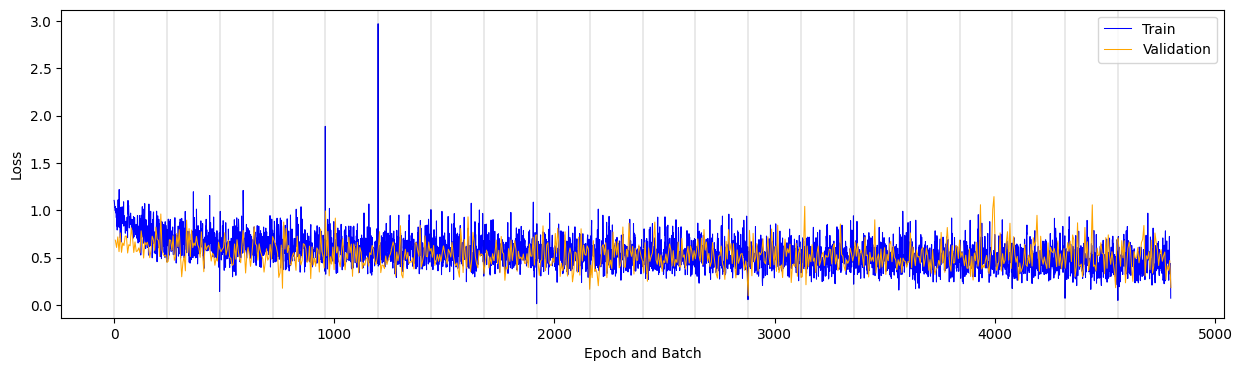

In [72]:
matplotlib.rc('figure', figsize=(15,4))
val_ticks = [(i+1)*len(losses['train'])/len(losses['val']) for i in range(len(losses['val']))]
plt.plot(range(len(losses['train'])), losses['train'], c='blue', lw=0.75)
plt.plot(val_ticks, losses['val'], c='orange', lw=0.75)
for i in range(num_epochs):
    plt.axvline(x=i*len(losses['train'])/num_epochs, c='black', lw=0.25, alpha=0.5)
plt.ylabel('Loss')
plt.xlabel('Epoch and Batch')
plt.legend(('Train','Validation'))

In [73]:
# Test the model
model_w_embeddings.eval()
dataset.set_split('val')
y_true = []
y_pred = []

with torch.no_grad():
    correct = 0
    total = 0
    for batch_data in dataloader:
        tweets = batch_data['x'].to(device)
        labels = batch_data['y'].to(device)
        outputs = model_w_embeddings(tweets)
        _, predicted = torch.max(outputs.data, 1)
        y_true += labels.tolist()
        y_pred += predicted.tolist()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Accuracy (on {len(dataloader)*batch_size} validation tweets): {100 * correct / total:.2f}%")


Accuracy (on 1376 validation tweets): 80.67%


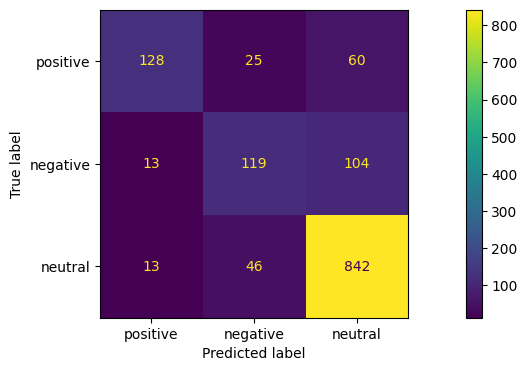

In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['positive','negative','neutral'])
disp.plot()

In [75]:
# length of an input is
len(dataset[0]['x'])

100

In [76]:
import torchinfo
torchinfo.summary(model_w_embeddings, tuple(dataset[0]['x'].size()))

Layer (type:depth-idx)                   Output Shape              Param #
AirlineTweetClassifier                   [3]                       --
├─Linear: 1-1                            [256]                     25,856
├─Linear: 1-2                            [32]                      8,224
├─Dropout: 1-3                           [32]                      --
├─Linear: 1-4                            [3]                       99
Total params: 34,179
Trainable params: 34,179
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 6.88
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.14
Estimated Total Size (MB): 0.14

In [77]:
100*256 + 256

25856

---

### Q3: How much smaller is the model with embeddings than the model with one-hot encoded inputs?


`One hot encoded parameters: 496,131. Embeddings parameters: 34,179`

---